
# Detailed Blockchain Lab Notebook with Visualizations
This notebook provides:
- Clear explanations for each concept
- A full blockchain implementation
- Proof-of-Work, difficulty, transactions, mining rewards
- Mining time visualization
---


**Note:
A real blockchain is a distributed system with multiple nodes, networks, consensus rules, and security mechanisms.
This notebook provides only a simplified, single‑node demonstration for learning purposes.**

##  Imports

In [1]:
import hashlib  # for SHA‑256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints

**Block Class**

A block contains transactions and must be mined by finding a valid hash starting with a number of leading zeros determined by the difficulty.

In [2]:

class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.transactions = transactions # list of txs
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()  # compute hash

    def mine(self):
        target = '0' * self.difficulty  # target prefix
        start = time.time()             # start time
        attempts = 0                    # count tries
        while True:
            self.hash = self.compute_hash()  # calculate hash
            if self.hash.startswith(target):  # valid PoW?
                break
            self.nonce += 1                  # try next nonce
            attempts += 1
        return time.time() - start, attempts  # mining duration + attempts


##  Blockchain Class

The blockchain links blocks together and manages transactions, mining, verification, and exporting.

In [3]:

class Blockchain:
    def __init__(self, difficulty=3, reward=10):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty
        )
        b.mine()                       # mine genesis block
        self.chain.append(b)           # add to chain

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })                             # store pending tx

    def mine_pending(self, miner):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending            # include reward + pending txs
        prev = self.chain[-1]                       # last block
        b = Block(len(self.chain), time.time(), txs, prev.hash, self.difficulty)
        t, attempts = b.mine()                      # mine new block
        self.chain.append(b)                        # add block to chain
        self.pending = []                           # clear mempool
        return t, attempts                          # return mining stats

    def export_json(self, filename):
        data = [b.__dict__ for b in self.chain]     # serialize blocks
        s = json.dumps(data, indent=2)              # format JSON
        open(filename, 'w').write(s)                # write file
        return s                                    # return JSON string


## 🚀 Example: Create Blockchain and Add Transactions

In [4]:

bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 14.772207736968994 seconds
Attempts: 868513


In [5]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")
    print(f" Transactions: {b.transactions}")
    print("-" * 50)

Block #0
 Timestamp   : 1774325277.6144795
 Hash        : 00000355ebd19eacbaff4254ad2273effdd11edcee809e878fa1743da52d339c
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 2209933
 Transactions: [{'sender': 'network', 'recipient': 'genesis', 'amount': 0}]
--------------------------------------------------
Block #1
 Timestamp   : 1774325307.7601306
 Hash        : 00000deb5ada643bfa3da258d7ee0b155f056c229f95eb4f12fff8e8e9c191d1
 Prev Hash   : 00000355ebd19eacbaff4254ad2273effdd11edcee809e878fa1743da52d339c
 Difficulty  : 5
 Nonce       : 868513
 Transactions: [{'sender': 'network', 'recipient': 'Miner1', 'amount': 25}, {'sender': 'Alice', 'recipient': 'Bob', 'amount': 10}, {'sender': 'Bob', 'recipient': 'Charlie', 'amount': 5}, {'sender': 'Charlie', 'recipient': 'Dave', 'amount': 2}]
--------------------------------------------------


## Mining Time Visualization

We test multiple difficulty levels and plot the mining times to show how difficulty impacts mining cost.

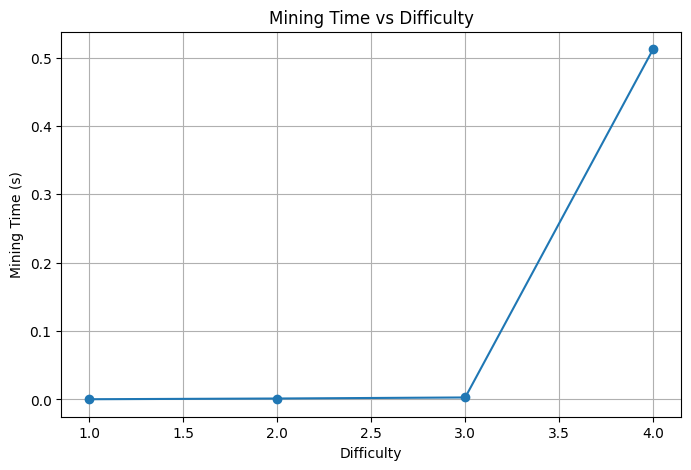

In [6]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    bc = Blockchain(difficulty=d, reward=1)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


#  Student Challenges
1. Note that your data is not encrypted inside the blocks, so anyone can read it. Encrypt the data before storing it in each block. Use encryption methods such as AES or 3DES.

2. Modify the mining function so it no longer uses leading‑zero matching; instead apply a different Proof‑of‑Work rule, such as a numeric hash threshold, pattern matching, or a time‑limited mining attempt.

Some options can be:

* Numeric threshold: Convert the hash to an integer and check if it's below a target value.
* Pattern rule: Make the hash end with certain characters (e.g., "00"), or require a substring inside the hash.
* Time‑limited PoW: Stop mining after a fixed time or attempt limit and mark the block as failed.
* Difficulty idea: Control difficulty by adjusting pattern length or the numeric target size.


# LAB-LOGBOOK requirement:
Show a graph comparing the mining time of the different Proof‑of‑Work methods used in Challenge 2.









In [7]:
!pip install cryptography


In [8]:
from cryptography.fernet import Fernet
import json
import hashlib
import time

encryption_key = Fernet.generate_key()
cipher = Fernet(encryption_key)

class EncryptedBlock:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty):
        self.index = index
        self.timestamp = timestamp
        tx_string = json.dumps(transactions)
        self.encrypted_transactions = cipher.encrypt(tx_string.encode()).decode('utf-8')
        self.previous_hash = previous_hash
        self.difficulty = difficulty
        self.nonce = 0
        self.hash = None

    def get_decrypted_transactions(self):
        decrypted = cipher.decrypt(self.encrypted_transactions.encode())
        return json.loads(decrypted.decode('utf-8'))

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "encrypted_transactions": self.encrypted_transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()

    def mine(self):
        target = '0' * self.difficulty
        start = time.time()
        attempts = 0
        while True:
            self.hash = self.compute_hash()
            if self.hash.startswith(target):
                break
            self.nonce += 1
            attempts += 1
        return time.time() - start, attempts

# Challenge 1
transactions = [{"sender": "Alice", "recipient": "Bob", "amount": 50}]
eb = EncryptedBlock(1, time.time(), transactions, "0"*64, 2)
t, att = eb.mine()
print("Encrypted Data stored in block:", eb.encrypted_transactions)
print("Decrypted Data from block:", eb.get_decrypted_transactions())


Encrypted Data stored in block: gAAAAABpwg5Rhjg36PO7KmNrdirQ33cP4F6hW2l2QD9cqMeUdCqCmdYJvH_ORQ9Etu2U0McUAQ_KF7QqM0ZXAhb0CyrTKDeIikK4-pLUoXXo5AHmJ-gJ1ouiqn5Xc4bNh2DXBPC4UZZ4f2AMqXo95wPr6HlC2MwquQ==
Decrypted Data from block: [{'sender': 'Alice', 'recipient': 'Bob', 'amount': 50}]


In [9]:
class MultiPoWBlock:
    def __init__(self, index, timestamp, transactions, previous_hash, pow_method='leading_zeros', difficulty_param=3):
        self.index = index
        self.timestamp = timestamp
        self.transactions = transactions
        self.previous_hash = previous_hash
        self.pow_method = pow_method
        self.difficulty_param = difficulty_param
        self.nonce = 0
        self.hash = None

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "pow_method": self.pow_method,
            "difficulty_param": self.difficulty_param,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()

    def is_valid_pow(self):
        if self.pow_method == 'leading_zeros':
            target = '0' * self.difficulty_param
            return self.hash.startswith(target)

        elif self.pow_method == 'numeric_threshold':
            target_val = (2**256 - 1) // (16 ** self.difficulty_param)
            hash_val = int(self.hash, 16)
            return hash_val < target_val

        elif self.pow_method == 'pattern_matching':
            return self.hash.endswith(str(self.difficulty_param))

        return False

    def mine(self):
        start = time.time()
        attempts = 0
        while True:
            self.hash = self.compute_hash()
            if self.is_valid_pow():
                break
            self.nonce += 1
            attempts += 1
        return time.time() - start, attempts


Method [leading_zeros] with parameter [1]: 0.0001 seconds
Method [leading_zeros] with parameter [2]: 0.0006 seconds
Method [leading_zeros] with parameter [3]: 0.0248 seconds
Method [leading_zeros] with parameter [4]: 2.4295 seconds
Method [numeric_threshold] with parameter [1]: 0.0000 seconds
Method [numeric_threshold] with parameter [2]: 0.0013 seconds
Method [numeric_threshold] with parameter [3]: 0.0605 seconds
Method [numeric_threshold] with parameter [4]: 4.7034 seconds
Method [pattern_matching] with parameter [a]: 0.0007 seconds
Method [pattern_matching] with parameter [ab]: 0.0154 seconds
Method [pattern_matching] with parameter [abc]: 0.1200 seconds
Method [pattern_matching] with parameter [abcd]: 1.3624 seconds


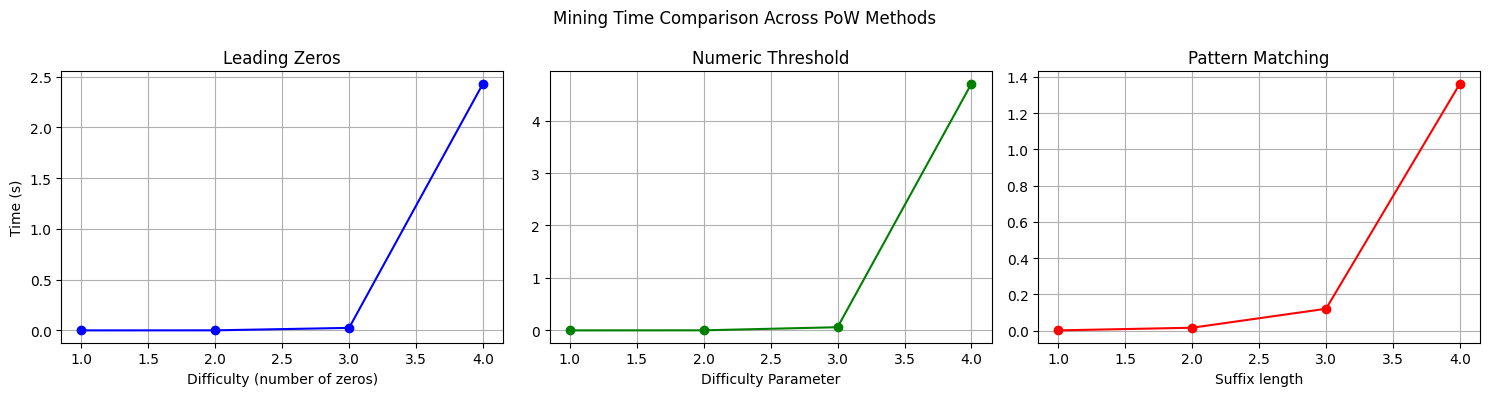

In [10]:
test_cases = [
    {'method': 'leading_zeros', 'configs': [1, 2, 3, 4]},
    {'method': 'numeric_threshold', 'configs': [1, 2, 3, 4]},
    {'method': 'pattern_matching', 'configs': ['a', 'ab', 'abc', 'abcd']}
]

results = { 'leading_zeros': [], 'numeric_threshold': [], 'pattern_matching': [] }
txs = [{"sender": "A", "recipient": "B", "amount": 10}]

for case in test_cases:
    m = case['method']
    for diff in case['configs']:
        block = MultiPoWBlock(1, time.time(), txs, "0"*64, pow_method=m, difficulty_param=diff)
        t, att = block.mine()
        results[m].append(t)
        print(f"Method [{m}] with parameter [{diff}]: {t:.4f} seconds")

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Mining Time Comparison Across PoW Methods")

axs[0].plot(test_cases[0]['configs'], results['leading_zeros'], marker='o', color='blue')
axs[0].set_title('Leading Zeros')
axs[0].set_xlabel('Difficulty (number of zeros)')
axs[0].grid(True)
axs[0].set_ylabel('Time (s)')

axs[1].plot(test_cases[1]['configs'], results['numeric_threshold'], marker='o', color='green')
axs[1].set_title('Numeric Threshold')
axs[1].grid(True)
axs[1].set_xlabel('Difficulty Parameter')

axs[2].plot([len(str(x)) for x in test_cases[2]['configs']], results['pattern_matching'], marker='o', color='red')
axs[2].set_title('Pattern Matching')
axs[2].grid(True)
axs[2].set_xlabel('Suffix length')

plt.tight_layout()
plt.show()
